# Stage 2: Returns and Risk

This notebook transforms Stage 1 price data into portfolio-ready return and volatility outputs. It keeps the runtime Yahoo Finance access pattern unchanged and performs all analytics in memory.

## Why Returns and Volatility Matter

- Portfolio optimization does not use raw prices directly because assets trade at different absolute price levels.
- Returns convert price changes into a comparable scale across assets.
- Simple returns are intuitive percentage changes.
- Log returns are additive through time and are the default Stage 2 output for downstream risk analysis.
- Volatility measures how much returns vary over time and serves as a first-pass risk proxy before covariance and correlation are studied in later stages.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_pipeline import SAMPLE_UNIVERSE, DataPreprocessor, YahooFinanceProvider

In [2]:
symbols = list(SAMPLE_UNIVERSE)
start_date = "2022-01-01"
end_date = "2024-12-31"

provider = YahooFinanceProvider()
market_data = provider.get_market_data(symbols, start_date, end_date)

prices_df = DataPreprocessor.handle_missing_values(market_data.prices_df)
volume_df = market_data.volume_df.copy()

stage_2_outputs = DataPreprocessor.build_returns_risk_outputs(prices_df)

simple_returns_df = stage_2_outputs.simple_returns_df
returns_df = stage_2_outputs.returns_df
log_returns_df = stage_2_outputs.log_returns_df
volatility_summary_df = stage_2_outputs.volatility_summary_df
rolling_volatility_df = stage_2_outputs.rolling_volatility_df
return_comparison_df = stage_2_outputs.return_comparison_df

print(f"prices_df shape: {prices_df.shape}")
print(f"volume_df shape: {volume_df.shape}")
print(f"simple_returns_df shape: {simple_returns_df.shape}")
print(f"log_returns_df shape: {log_returns_df.shape}")
print(f"rolling_volatility_df shape: {rolling_volatility_df.shape}")

prices_df shape: (738, 3)
volume_df shape: (738, 3)
simple_returns_df shape: (737, 3)
log_returns_df shape: (737, 3)
rolling_volatility_df shape: (737, 6)


In [3]:
prices_df.head()

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2022-01-03,41.730000,722.802551,3341.056396
2022-01-04,41.459999,727.035706,3399.690186
2022-01-05,41.560001,744.301270,3378.862061
2022-01-06,41.240002,732.362854,3332.041992
2022-01-07,41.090000,737.499756,3372.342285


In [4]:
display(simple_returns_df.head())
display(log_returns_df.head())
display(return_comparison_df)
display(volatility_summary_df)

Ticker,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2022-01-04,-0.006470,0.005857,0.017549
2022-01-05,0.002412,0.023748,-0.006126
2022-01-06,-0.007700,-0.016040,-0.013857
2022-01-07,-0.003637,0.007014,0.012095
2022-01-10,-0.000487,0.005546,0.006838


asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
Date,,,
2022-01-04,-0.006491,0.005840,0.017397
2022-01-05,0.002409,0.023470,-0.006145
2022-01-06,-0.007729,-0.016170,-0.013954
2022-01-07,-0.003644,0.006990,0.012022
2022-01-10,-0.000487,0.005531,0.006815


,mean_simple_return,mean_log_return,mean_abs_difference,max_abs_difference,return_correlation
asset,,,,,
GOLDBEES.NS,0.000609,0.000580,0.000028,0.000616,0.999970
HDFCBANK.NS,0.000358,0.000263,0.000095,0.004702,0.999793
TCS.NS,0.000295,0.000208,0.000087,0.002107,0.999907


,daily_volatility,annualized_volatility,annualization_factor
asset,,,
GOLDBEES.NS,0.007500,0.119059,252
HDFCBANK.NS,0.013805,0.219153,252
TCS.NS,0.013173,0.209110,252


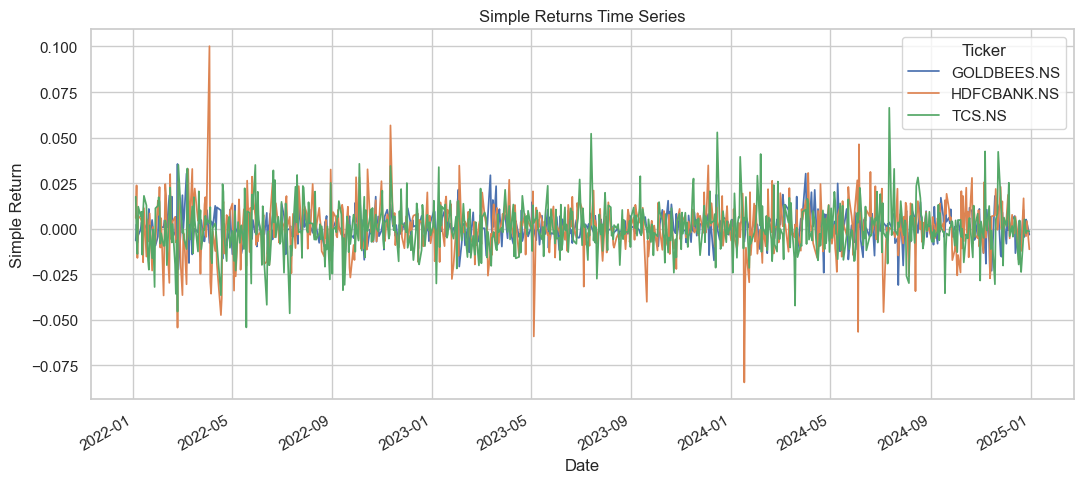

In [5]:
sns.set_theme(style="whitegrid")
ax = simple_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Simple Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Simple Return")
plt.tight_layout()

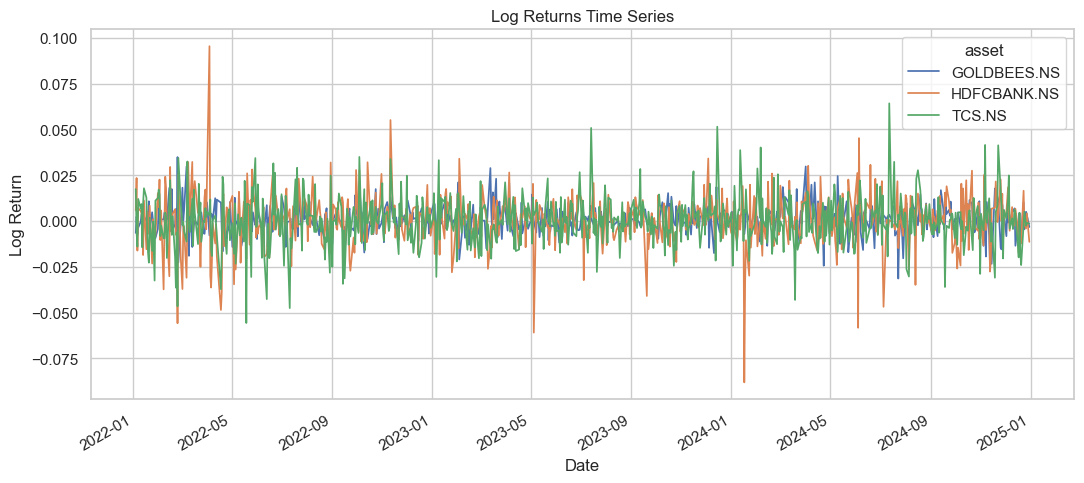

In [6]:
ax = log_returns_df.plot(figsize=(11, 5), linewidth=1.25)
ax.set_title("Log Returns Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
plt.tight_layout()

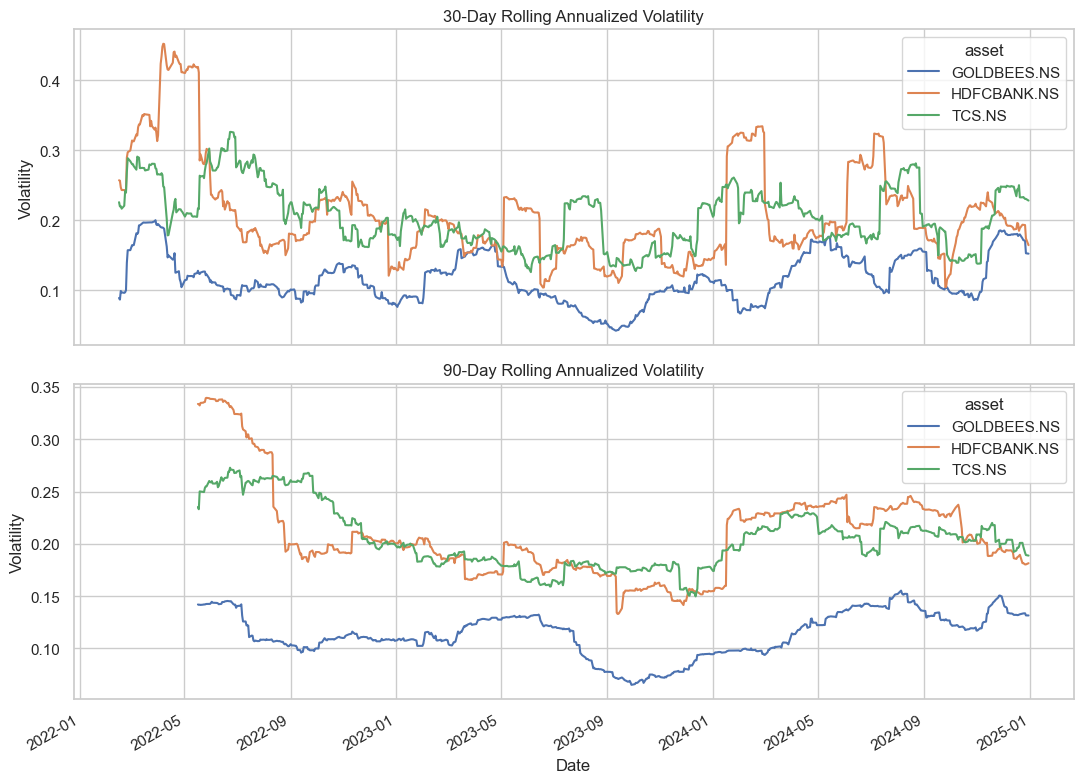

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
rolling_volatility_df.xs("30d", axis=1, level="window").plot(ax=axes[0], linewidth=1.5)
axes[0].set_title("30-Day Rolling Annualized Volatility")
axes[0].set_ylabel("Volatility")

rolling_volatility_df.xs("90d", axis=1, level="window").plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("90-Day Rolling Annualized Volatility")
axes[1].set_ylabel("Volatility")
axes[1].set_xlabel("Date")
plt.tight_layout()

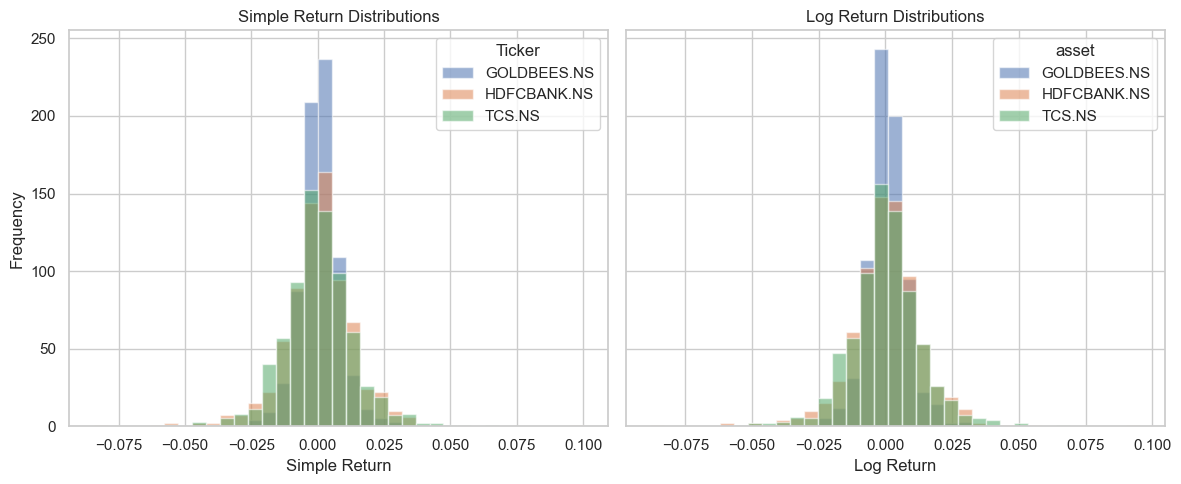

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
simple_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[0])
axes[0].set_title("Simple Return Distributions")
axes[0].set_xlabel("Simple Return")

log_returns_df.plot(kind="hist", bins=35, alpha=0.55, ax=axes[1])
axes[1].set_title("Log Return Distributions")
axes[1].set_xlabel("Log Return")
plt.tight_layout()

## Interpretation

- `returns_df` is intentionally set equal to `log_returns_df` so downstream stages default to log returns.
- The difference between simple and log returns is small for daily data, but log returns compose more cleanly across time.
- Annualized volatility scales daily dispersion by the square root of trading days and gives a comparable risk summary across assets.
- Rolling volatility reveals how risk changes over time, which is essential before building covariance and correlation matrices in the next approved stage.